In [2]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
from mplsoccer import  VerticalPitch, add_image
import cmasher as cmr
from PIL import Image 
import numpy as np


In [2]:
url = "https://www.sofascore.com/football/match/talaea-el-gaish-zamalek-sc/tXqslwr#id:12107397,tab:statistics"

curl "https://www.sofascore.com/api/v1/event/12461446/featured-players" ^
  -H "accept: */*" ^
  -H "accept-language: en-US,en;q=0.7" ^
  -H "cache-control: max-age=0" ^
  -H ^"if-none-match: W/^\^"bf67d39251^\^"^" ^
  -H "priority: u=1, i" ^
  -H "referer: https://www.sofascore.com/football/match/talaea-el-gaish-zamalek-sc/tXqslwr" ^
  -H ^"sec-ch-ua: ^\^"Not)A;Brand^\^";v=^\^"99^\^", ^\^"Brave^\^";v=^\^"127^\^", ^\^"Chromium^\^";v=^\^"127^\^"^" ^
  -H "sec-ch-ua-mobile: ?0" ^
  -H ^"sec-ch-ua-platform: ^\^"Windows^\^"^" ^
  -H "sec-fetch-dest: empty" ^
  -H "sec-fetch-mode: cors" ^
  -H "sec-fetch-site: same-origin" ^
  -H "sec-gpc: 1" ^
  -H "user-agent: Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/127.0.0.0 Safari/537.36" ^
  -H "x-requested-with: 6ba7b3"

In [3]:
headers = {
    "accept": "*/*",
    "accept-language": "en-US,en;q=0.5",
    "cache-control": "max-age=0",
    "priority": "u=1, i",
    "referer": "https://www.sofascore.com/football/match/talaea-el-gaish-zamalek-sc/tXqslwr",
    "sec-ch-ua": "\"Not)A;Brand\";v=\"99\", \"Brave\";v=\"127\", \"Chromium\";v=\"127\"",
    "sec-ch-ua-mobile": "?0",
    "sec-ch-ua-platform": "\"Windows\"",
    "sec-fetch-dest": "empty",
    "sec-fetch-mode": "cors",
    "sec-fetch-site": "same-origin",
    "sec-gpc": "1",
    "user-agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/127.0.0.0 Safari/537.36",
    "x-requested-with": "eb1a19"
}

In [4]:
response = requests.get('https://www.sofascore.com/api/v1/event/12107397/shotmap', headers =headers)

In [5]:
response.status_code

200

In [6]:
response.text

'{"shotmap":[{"player":{"name":"Ammar Mansour","firstName":"Ammar Mansour","slug":"ammar-mansour","shortName":"A. Mansour","position":"F","jerseyNumber":"41","userCount":15,"id":1879256},"isHome":false,"shotType":"miss","situation":"assisted","playerCoordinates":{"x":24.8,"y":29.4,"z":0},"bodyPart":"right-foot","goalMouthLocation":"high-right","goalMouthCoordinates":{"x":0,"y":39.7,"z":52.8},"id":3437465,"time":90,"addedTime":5,"timeSeconds":5641,"draw":{"start":{"x":29.4,"y":24.8},"end":{"x":60.3,"y":0},"goal":{"x":60.3,"y":47.2}},"reversedPeriodTime":1,"reversedPeriodTimeSeconds":659,"incidentType":"shot"},{"player":{"name":"Youssry Wahid","firstName":"Youssry Wahid","slug":"youssry-wahid","shortName":"Y. Wahid","position":"M","jerseyNumber":"19","userCount":50,"id":1525731},"isHome":true,"shotType":"miss","situation":"regular","playerCoordinates":{"x":19.1,"y":39.9,"z":0},"bodyPart":"left-foot","goalMouthLocation":"left","goalMouthCoordinates":{"x":0,"y":62.4,"z":6.9},"id":3437464,"

In [7]:

data =json.loads(response.text)
df =pd.DataFrame(data)
df = pd.json_normalize(data['shotmap'])
pd.set_option('display.max_columns', None)

df.head(5)


,isHome,shotType,situation,bodyPart,goalMouthLocation,id,time,addedTime,timeSeconds,reversedPeriodTime,reversedPeriodTimeSeconds,incidentType,player.name,player.firstName,player.slug,player.shortName,player.position,player.jerseyNumber,player.userCount,player.id,playerCoordinates.x,playerCoordinates.y,playerCoordinates.z,goalMouthCoordinates.x,goalMouthCoordinates.y,goalMouthCoordinates.z,draw.start.x,draw.start.y,draw.end.x,draw.end.y,draw.goal.x,draw.goal.y,player.lastName,blockCoordinates.x,blockCoordinates.y,blockCoordinates.z,draw.block.x,draw.block.y,goalType
0,False,miss,assisted,right-foot,high-right,3437465,90,5.0,5641,1,659,shot,Ammar Mansour,Ammar Mansour,ammar-mansour,A. Mansour,F,41,15,1879256,24.8,29.4,0,0,39.7,52.8,29.4,24.8,60.3,0,60.3,47.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,True,miss,regular,left-foot,left,3437464,87,NaN,5209,4,191,shot,Youssry Wahid,Youssry Wahid,youssry-wahid,Y. Wahid,M,19,50,1525731,19.1,39.9,0,0,62.4,6.9,39.9,19.1,37.6,0,37.6,93.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,True,save,assisted,right-foot,low-right,3437442,84,NaN,5019,7,381,shot,Ali Hamdy,,ali-hamdy,A. Hamdy,M,20,15,1169229,28.6,62.0,0,0,47.1,10.8,62.0,28.6,52.9,0,52.9,89.2,,3.1,51.4,0.0,51.4,3.1,NaN
3,False,block,assisted,left-foot,low-right,3437463,83,NaN,4977,8,423,shot,Ibrahima Ndiaye,NaN,ibrahima-ndiaye,I. Ndiaye,M,NaN,360,880777,13.2,72.1,0,0,47.4,19.0,72.1,13.2,52.6,0,52.6,81.0,NaN,10.5,68.1,0.0,68.1,10.5,NaN
4,True,goal,assisted,right-foot,low-right,3437406,69,NaN,4086,22,1314,shot,Ahmed El Sheikh,,el-sheikh-ahmed,A. E. Sheikh,F,7,28,918874,4.0,60.1,0,0,48.1,19.6,60.1,4.0,51.9,0,51.9,80.4,,NaN,NaN,NaN,NaN,NaN,regular


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   isHome                     25 non-null     bool   
 1   shotType                   25 non-null     object 
 2   situation                  25 non-null     object 
 3   bodyPart                   25 non-null     object 
 4   goalMouthLocation          25 non-null     object 
 5   id                         25 non-null     int64  
 6   time                       25 non-null     int64  
 7   addedTime                  2 non-null      float64
 8   timeSeconds                25 non-null     int64  
 9   reversedPeriodTime         25 non-null     int64  
 10  reversedPeriodTimeSeconds  25 non-null     int64  
 11  incidentType               25 non-null     object 
 12  player.name                25 non-null     object 
 13  player.firstName           20 non-null     object 
 

In [8]:
df= df.loc[df['isHome']==False]

df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 0 to 22
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   isHome                     10 non-null     bool   
 1   shotType                   10 non-null     object 
 2   situation                  10 non-null     object 
 3   bodyPart                   10 non-null     object 
 4   goalMouthLocation          10 non-null     object 
 5   id                         10 non-null     int64  
 6   time                       10 non-null     int64  
 7   addedTime                  1 non-null      float64
 8   timeSeconds                10 non-null     int64  
 9   reversedPeriodTime         10 non-null     int64  
 10  reversedPeriodTimeSeconds  10 non-null     int64  
 11  incidentType               10 non-null     object 
 12  player.name                10 non-null     object 
 13  player.firstName           7 non-null      object 
 14  p

In [41]:
df['shotType']

0      miss
3     block
8      save
9      goal
12     goal
13     miss
19     save
20    block
21     miss
22    block
Name: shotType, dtype: object

Text(0.1, 0.699, "Zamalek SC's shot map")

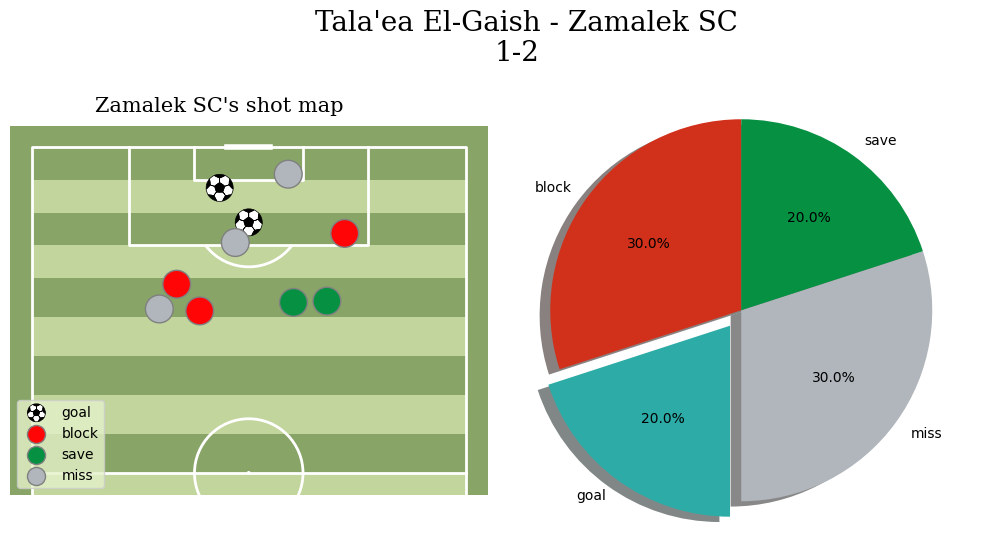

In [9]:
# Define the shot types and their corresponding properties
shot_types = {
    'goal': {'color': 'white', 'edgecolor': 'black', 'marker': 'football'},
    'block': {'color': '#ff0505', 'edgecolor': 'gray', 'marker': 'o'},
    'save': {'color': '#059042', 'edgecolor': 'gray', 'marker': 'o'},
    'miss': {'color': '#b0b6bb', 'edgecolor': 'gray', 'marker': 'o'}
}

fig, axs = plt.subplots(nrows=1, ncols=2,tight_layout=False,figsize=(10, 10))
# Initialize the pitch
pitch = VerticalPitch(pitch_color='#88a567', line_color='white',
                      stripe_color='#c2d59d', stripe=True, half=True)  # optional stripes
pitch.draw(ax=axs[0])


# Flip the x-coordinates
df['x'] = 100 - df['playerCoordinates.x']
df['size'] = 400

# Loop through each shot type and plot
for shot_type, props in shot_types.items():
    shot_data = df.loc[df['shotType'] == shot_type]
    pitch.scatter(x=shot_data['x'] * 1.2,
                  y=shot_data['playerCoordinates.y'] * 0.8,
                  s=shot_data['size'],
                  edgecolors=props['edgecolor'],
                  c=props['color'],
                  marker=props['marker'],
                  ax=axs[0],
                  label=shot_type)
axs[0].legend(facecolor ='#e5f2ca', loc ='lower left',markerscale=0.65)

sizes = df.groupby('shotType')['shotType'].count()

explode = (0, 0.1, 0, 0) 
pie = sizes.plot.pie(autopct='%1.1f%%', startangle=90, colors=['#d1311a', '#2daba7', '#b0b6bb', '#059042'],
explode=explode,shadow={'ox': -0.04, 'edgecolor': 'none', 'shade': 0.9})


pie.set(ylabel="")


fig.text(0.32,0.78,'Tala\'ea El-Gaish - Zamalek SC',fontfamily='serif',fontsize=20) 
fig.text(0.5,0.75,'1-2',fontfamily='serif',fontsize=20) 


fig.text(0.1,0.699,'Zamalek SC\'s shot map',fontfamily='serif',fontsize=15) 




In [10]:
players_id = [id for id in df['player.id']]
players_names = [name.replace(' ', '_').replace('-', '_') for name in df['player.name']]

players_id = set(players_id)
players_names = set(players_names)
#players_id
#players_names

In [252]:
players_names

{'Abdallah_El_Said',
 'Ahmed_Esho',
 'Ammar_Mansour',
 'Ibrahima_Ndiaye',
 'Mohamed_Atef',
 'Nasser_Maher',
 'Youssef_Obama'}

In [11]:

file_names = []  # Initialize the file_names list

for player_id, player_name in zip(players_id, players_names):
    # Get the heatmap data for the player
    response = requests.get(f"https://www.sofascore.com/api/v1/event/12107397/player/{player_id}/heatmap", headers=headers)
    
    heatmap_data = response.json()
    globals()[player_name] = heatmap_data
    file_names.append(player_name)
    df = pd.DataFrame(heatmap_data['heatmap'])
    # Store the DataFrame in a global variable with the player's name
    globals()[f"df_{player_name}"] = df
    

In [272]:
df_Abdallah_El_Said.head(5)

,x,y
0,81,68
1,40,22
2,69,23
3,64,22
4,65,41


In [12]:
players_heatmaps ={'Abdallah_El_Said': df_Abdallah_El_Said,
                   'Ahmed_Esho': df_Ahmed_Esho,
                   'Ammar_Mansour': df_Ammar_Mansour,
                   'Ibrahima_Ndiaye': df_Ibrahima_Ndiaye,
                   'Mohamed_Atef':df_Mohamed_Atef,
                   'Nasser_Maher': df_Nasser_Maher}

In [280]:
players_heatmaps

{'Abdallah_El_Said':      x   y
 0   81  68
 1   40  22
 2   69  23
 3   64  22
 4   65  41
 5   65  50
 6   65  50
 7   69  54
 8   75  50
 9   85  53
 10  68  24
 11  72  23
 12  69  20
 13  63  73
 14  83  27
 15  83  27
 16  63  34
 17  82   8
 18  54  21
 19  61  19
 20  93  57
 21  93  56
 22  55  73
 23  42  83
 24  49  50
 25  46  31
 26  68  19
 27  41  80
 28  71  23
 29  39  70
 30  45  53
 31  49  56
 32  63  25
 33  62  25
 34  67  46
 35  51  53
 36  58  49
 37  69  37
 38  63  36
 39  73   8
 40  68  20
 41  65  17
 42  49  49
 43  49  22
 44  60  15
 45  60  15
 46  70  60
 47  34  73
 48  47  74
 49  53  93
 50  57  84
 51  51  69
 52  58  34
 53  34  66,
 'Ahmed_Esho':      x   y
 0   26  90
 1   26  90
 2   23  83
 3   33  81
 4   35  69
 ..  ..  ..
 85  34  63
 86  76  14
 87  70  23
 88  26  43
 89  26  43
 
 [90 rows x 2 columns],
 'Ammar_Mansour':      x   y
 0   39  84
 1   57  28
 2   63  24
 3   58  26
 4   53  49
 ..  ..  ..
 71  67  20
 72  82  10
 73  49  5

In [13]:
icon = Image.open(r'C:\Users\A plus\sofascore\image.png')

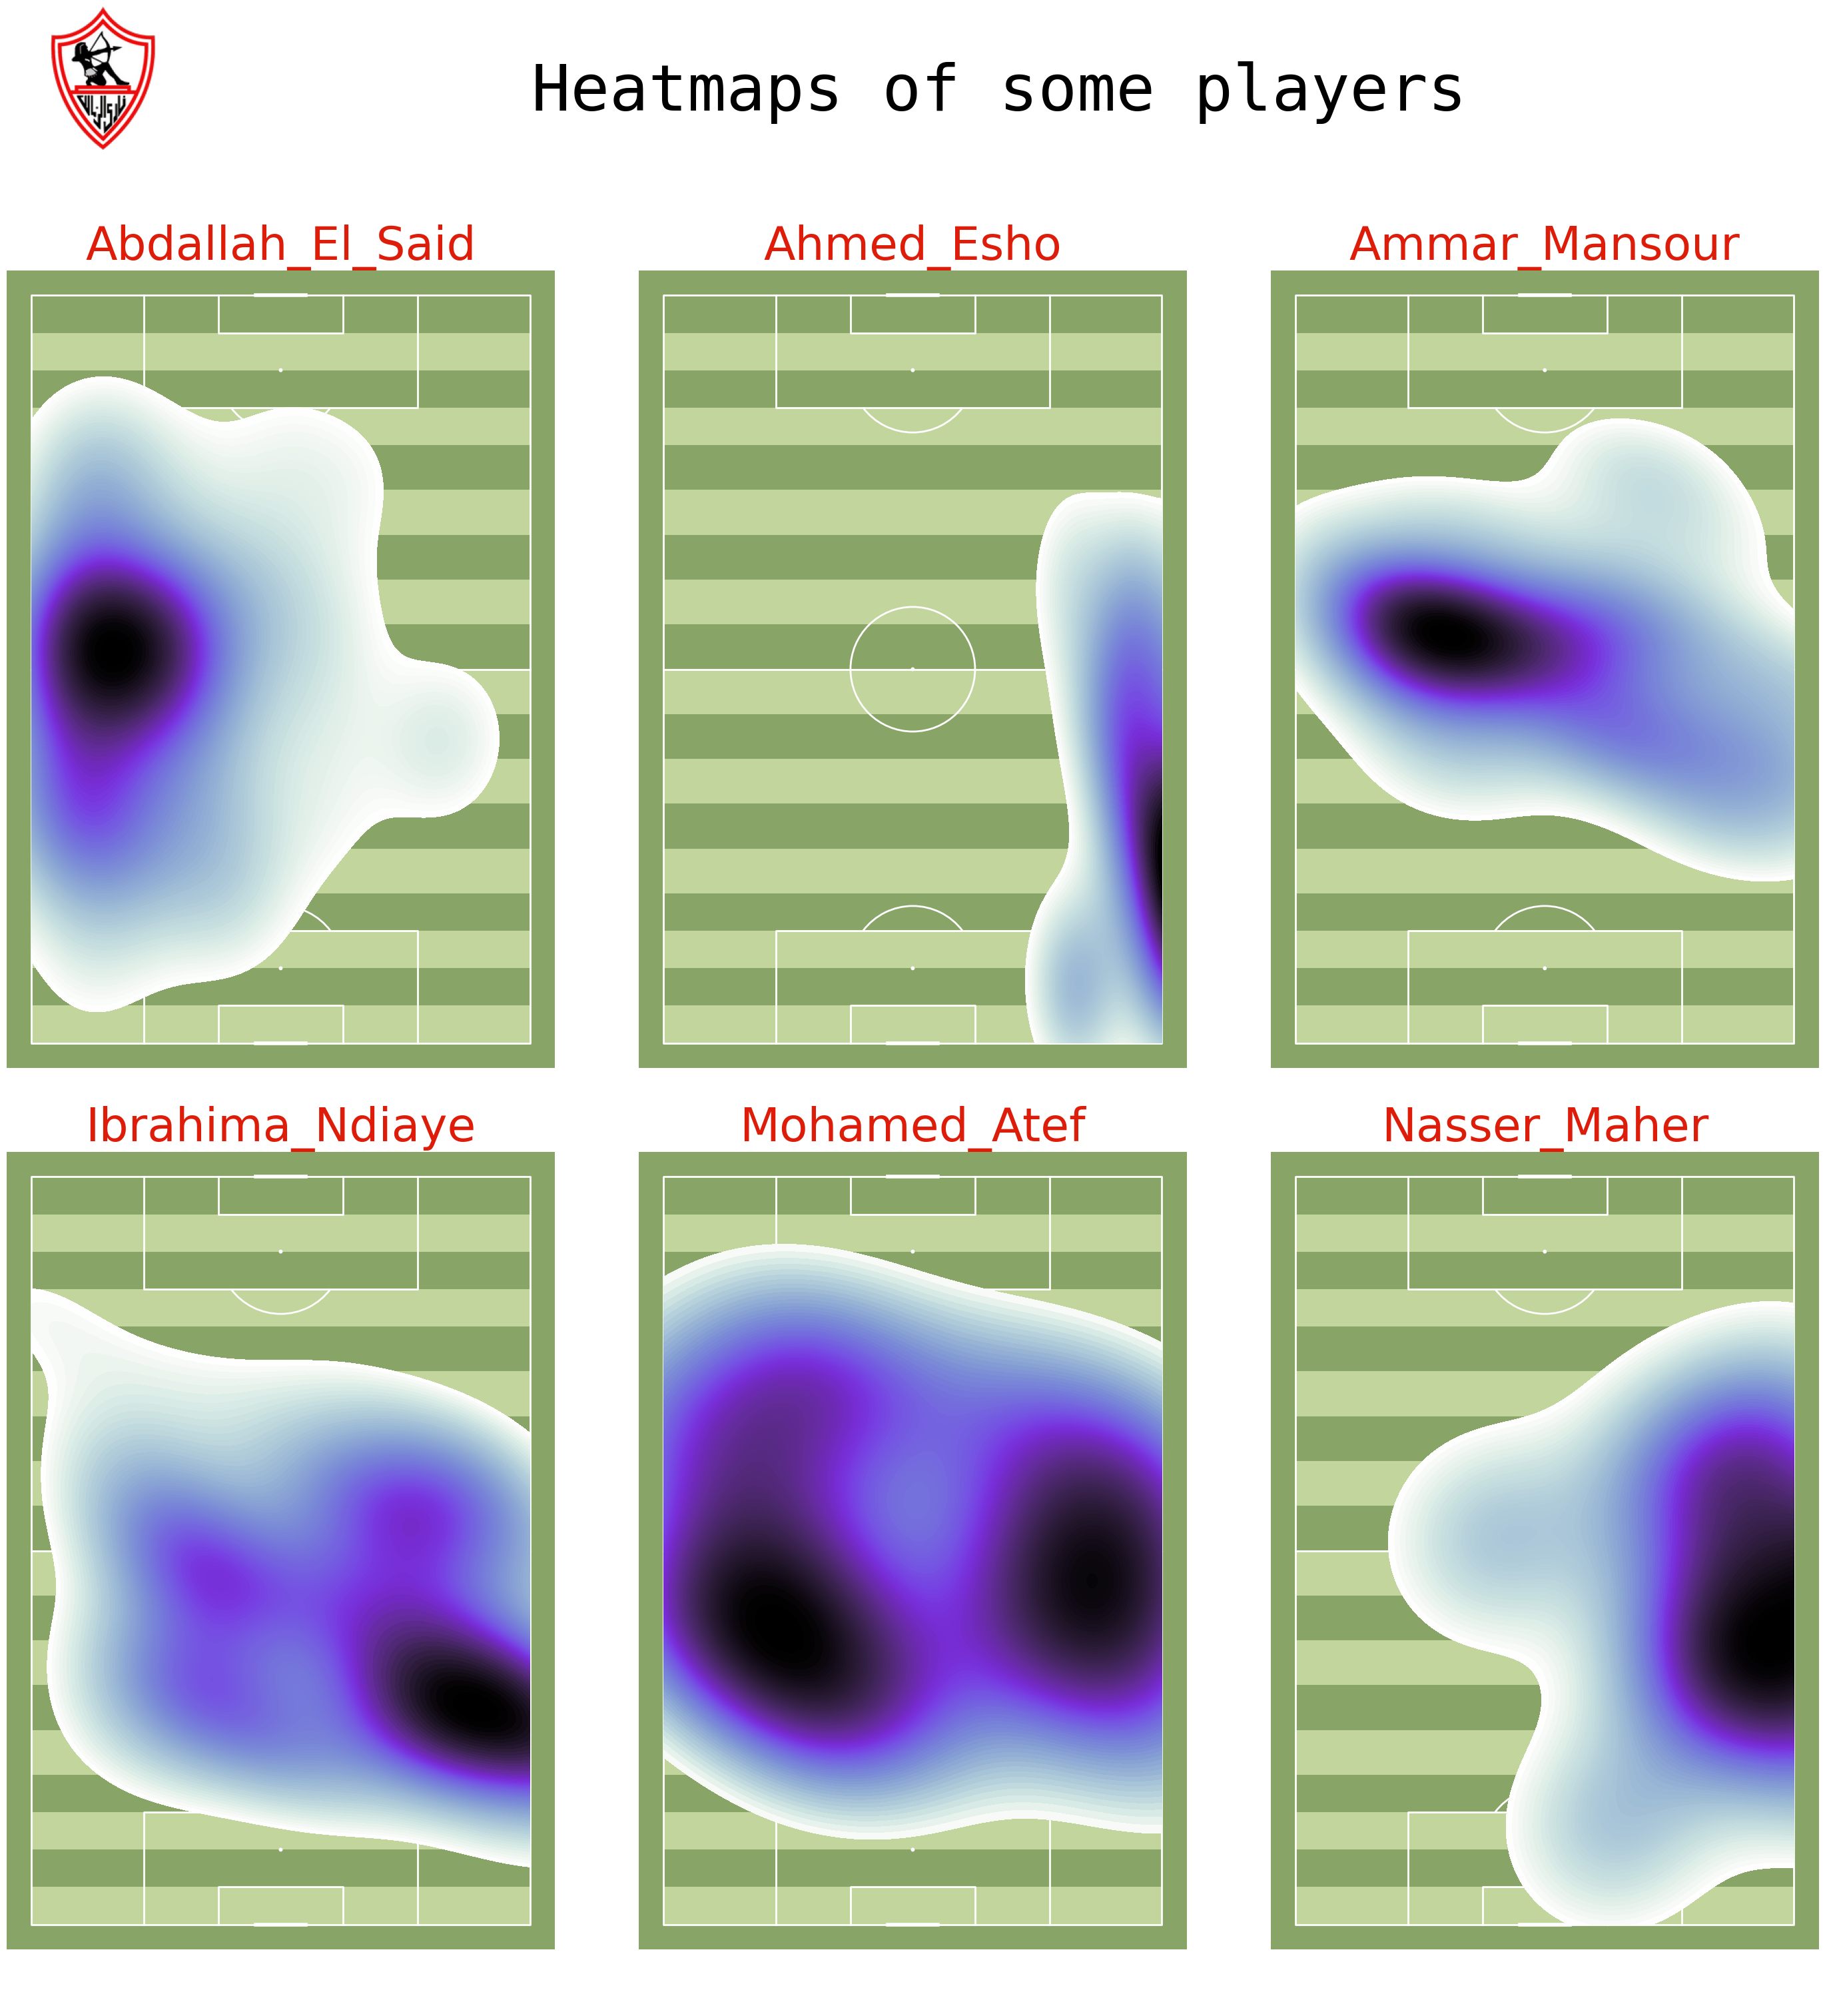

In [17]:
pitch = VerticalPitch(pitch_color='#88a567', line_color='white',
                      stripe_color='#c2d59d', stripe=True,)
fig, axs = pitch.grid(nrows=2, ncols=3, figheight=30,
                      endnote_height=0.03, endnote_space=0,
                      # Turn off the endnote/title axis. I usually do this after
                      # I am happy with the chart layout and text placement
                      axis=False,
                      title_height=0.08, grid_height=0.84)

#fig, ax = pitch.grid(ncols=1, axis=False, endnote_height=0.05)





for ax,heatdata in zip(axs['pitch'].flat,players_heatmaps):
    kdeplot = pitch.kdeplot(players_heatmaps[heatdata].x, players_heatmaps[heatdata].y, ax=ax,  fill=True, levels=100, cmap =cmr.amethyst_r)
    ax_title = ax.set_title(str(heatdata), fontsize=50, fontfamily ='sans-serif', color = '#dd1c09')

    

fig.text(0.3,0.97,'Heatmaps of some players',fontfamily='monospace',fontsize=70) 


ax_y = add_image(icon, fig,
                     # set the left, bottom and height
                     left=axs['title'].get_position().x0,
                     bottom=axs['title'].get_position().y0+0.05,
                     height=axs['title'].get_position().height*0.9)



https://www.sofascore.com/api/v1/player/943788/attribute-overviews
https://www.sofascore.com/api/v1/player/1008303/attribute-overviews
https://www.sofascore.com/api/v1/event/12461446/featured-players

In [18]:
response = requests.get('https://www.sofascore.com/api/v1/event/12461446/featured-players', headers = headers)
response.text



'{"home":{"player":{"name":"Mostafa El Zenary","firstName":"","lastName":"","slug":"mostafa-el-zenary","shortName":"M. E. Zenary","position":"D","jerseyNumber":"6","userCount":166,"id":1008303},"statistics":{"rating":"7.5"},"eventId":12463083},"away":{"player":{"name":"Ahmed Abdel Rahman Zola","slug":"ahmed-abdel-rahman-zola","shortName":"A. A. Zola","position":"D","jerseyNumber":"8","userCount":20,"id":943788},"statistics":{"rating":"8.3"},"eventId":12461455}}'

In [19]:
data =json.loads(response.text)
df =pd.DataFrame(data)
df_home = pd.json_normalize(data['home'])
df_away = pd.json_normalize(data['away'])

In [20]:
def get_attributes(dfha):
    id = str(dfha['player.id'][0])
    response = requests.get('https://www.sofascore.com/api/v1/player/'+id+'/attribute-overviews', headers = headers)
    data=json.loads(response.text)
    df =pd.DataFrame(data['playerAttributeOverviews'])
    df = df.drop(['position','yearShift','id'],axis=1)

    return  df




In [21]:
Mostafa_El_Zenary= get_attributes(df_home)
Ahmed_Abdel_Rahman_Zola = get_attributes(df_away)


In [22]:
Ahmed_Abdel_Rahman_Zola=Ahmed_Abdel_Rahman_Zola.drop(0, axis=0)

In [23]:
Mostafa_El_Zenary =Mostafa_El_Zenary.melt(var_name='Attribute', value_name='Value')
Ahmed_Abdel_Rahman_Zola = Ahmed_Abdel_Rahman_Zola.melt(var_name='Attribute', value_name='Value')

In [24]:
Mostafa_El_Zenary = pd.concat([Mostafa_El_Zenary, Mostafa_El_Zenary.iloc[[0]]], ignore_index=True)
Ahmed_Abdel_Rahman_Zola = pd.concat([Ahmed_Abdel_Rahman_Zola, Ahmed_Abdel_Rahman_Zola.iloc[[0]]], ignore_index=True)


Text(1.1, 0.7, '\nwe can see that Mostafa is better than\nAhmed in defending and technic but Ahmed\nis better than Mostafa in attacking and \ncreativity. Both are the same at tactics \n')

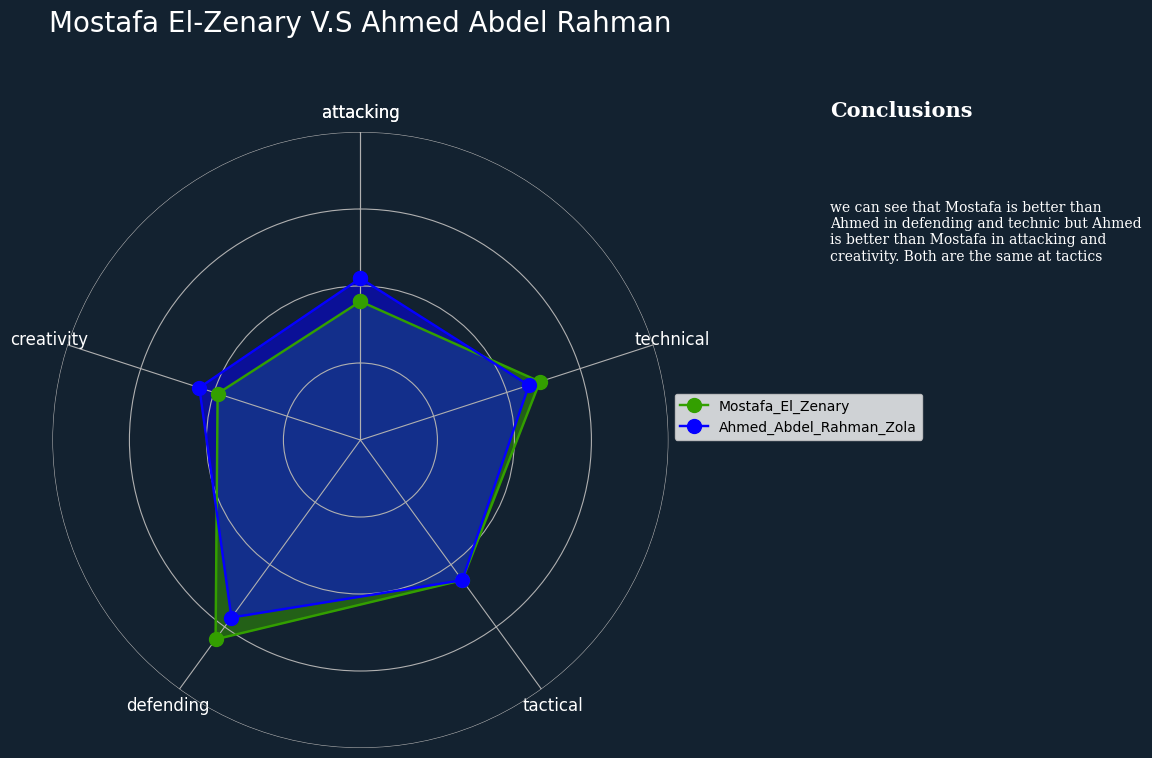

In [136]:
N = 5

theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
theta = np.concatenate([theta, [theta[0]]])
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
# Title
ax.set_title('Mostafa El-Zenary V.S Ahmed Abdel Rahman', y=1.15, fontsize=20, color='white')

# Direction of the zero angle to the north (upwards)
ax.set_theta_zero_location("N")

# Direction of the angles to be counterclockwise
ax.set_theta_direction(-1)

# Radial label position (position of values on the radial axes)
ax.set_rlabel_position(90)

# Make radial gridlines appear behind other elements
ax.spines['polar'].set_zorder(1)



# Set radial gridlines to the same color as the background
ax.spines['polar'].set_color('#132230')  # Same color as the background

# Set the face color of the axes to the background color
ax.set_facecolor('#132230')

fig.set_facecolor('#132230')

color_palette = ['#339F00', '#0500FF']
ax.plot(theta, Mostafa_El_Zenary['Value'], linewidth=1.75, linestyle='solid', label='Mostafa_El_Zenary',
         marker='o', markersize=10, color=color_palette[0])
ax.fill(theta, Mostafa_El_Zenary['Value'], alpha=0.50, color=color_palette[0])

ax.plot(theta, Ahmed_Abdel_Rahman_Zola['Value'], linewidth=1.75, linestyle='solid', label='Ahmed_Abdel_Rahman_Zola',
         marker='o', markersize=10, color=color_palette[1])
ax.fill(theta, Ahmed_Abdel_Rahman_Zola['Value'], alpha=0.50, color=color_palette[1])



plt.yticks([0, 20, 40,60, 80], ["", "", "", "", ""], color = 'white')
plt.xticks(theta,  Ahmed_Abdel_Rahman_Zola['Attribute'], color='white', size=12)

plt.legend(loc=(1.01,0.5))

#plt.axhline(y = 0, color = 'white', linewidth = 1.3, alpha = .7)

fig.text(1.1, 0.9, 'Conclusions', fontsize=15, fontweight='bold', fontfamily='serif',color ='white')

fig.text(1.1, 0.7, '''
we can see that Mostafa is better than
Ahmed in defending and technic but Ahmed
is better than Mostafa in attacking and 
creativity. Both are the same at tactics 
'''
         , fontsize=10, fontweight='light', fontfamily='serif', color ='white')

